# Снижение размерности данных

Под размерностью данных понимают размерность пространства признаков, то есть количество признаков.

Большая размерность может серьезно усложнить задачу анализа данных и даже стать причиной некорректной работы некоторых алгоритмов. Кроме того, часто в исходных данных могут присутствовать лишние признаки, никак не связанные с целевой переменной. Поэтому часто встает задача понижения количества признаков. Два подхода:
- оставить только самые значимые признаки (наиболее сильно влияющие на целевую переменную)
- сформировать новые признаки в меньшем количестве на основе всех старых признаков.

Будем решать задачу перехода от пространства большей размерности к пространству меньшей размерности с сохранением максимального количества полезной информации.

## Отбор признаков

Оценка предсказательной силы признака (или силы связи этого признака и целевой переменной) может проводиться, например с использованием коэффициента корреляции Пирсона (для задачи регрессии):

$$r_{xy} = \frac{\sum_{i=1}^{n}(x_{i} - \bar{x})(y_{i} - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_{i} - \bar{x})^{2}\sum_{i=1}^{n}(y_{i} - \bar{y})^{2}}},$$ где $\bar{x}$ и $\bar{y}$ - среднее значение признака и целевой переменной, соответственно. Чем больше по модулю корреляция ($\pm 1$), тем информативнее признак. Следует заметить, что этот метод учитывает только линейную связь между признаком и целевой переменной.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

r = -7.01e-02


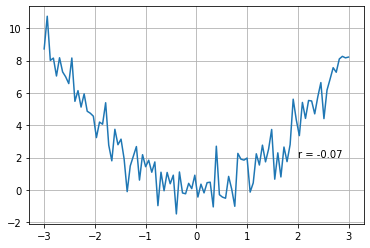

In [ ]:
x = np.linspace(-3, 3, 100)
y = x ** 2  + np.random.randn(100)
plt.plot(x, y)
plt.text(2, 2, f'r = {np.corrcoef(x, y)[0, 1]:.2f}')
plt.grid();
print(f'r = {np.corrcoef(x, y)[0, 1]:.2e}')

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=3)
x = np.linspace(-3, 3, 100)
y = x ** 2 + np.random.randn(100)
model.fit(x.reshape(-1, 1), y)
y_pred = model.predict(x.reshape(-1, 1))
print(f'r = {np.corrcoef(y_pred, y)[0, 1]:.2f}')

r = 0.94


Группа методов отбора признаков, встроенных в модели:

- в случае работы с линейными моделями мы имеем зависимость целевой переменной от взвешенной суммы $m$ признаков $$\hat{y}_i = \sum_{j=1}^{m}w_{j}x_{ij}.$$ Если признаки масштабированы, веса будут являться показателями информативности признаков: чем больше вес, тем больший вклад данный признак вносит в значение целевой переменной. На основе этого показателя можно проводить отбор признаков. Также использование $L_{1}$-регуляризации приводит к занулению весов наименее важных признаков, то есть к их отбрасыванию, при этом больший коэффициент регуляризации будет приводить к большему количеству зануленных весов;

- в случае использования решающих деревьев и их композиций, где в каждой вершине происходит разбиение на два поддерева путем сравнивания значения одного признака с некоторым значением порога, важность признака можно оценивать по тому, насколько он уменьшает значение критерия информативности, по которому оценивается качество разбиения: $$Q = H(X) - \frac{|X_{l}|}{|X|}H(X_{l}) - \frac{|X_{r}|}{|X|}H(X_{r}),$$ где $X$ - множество объектов, попавших в вершину на данном шаге, $X_{l}$ и $X_{r}$ - множества, попадающие в левое и правое поддерево, соответственно, после разбиения. $H(X)$ - критерий информативности.
    
    Чем сильнее падает критерий информативности при разбиении по данному признаку (то есть чем выше $Q$), тем этот признак важнее. Таким образом, важность $j$-го признака можно оценить путем вычисления суммы уменьшений критерия информативности по всем вершинам, в которых делалось разбиение по данному признаку. Чем больше эта сумма, тем важнее данный признак был при построении дерева. В случае композиций деревьев этот показатель суммируется по всем деревьям.

## Понижение размерности путем формирования новых признаков на основе старых

Новых признаков при использовании такого метода должно быть меньше, чем исходных, при условии сохранения максимально возможного количества информации из исходных признаков.

### PCA - Метод главных компонент

Одним из наиболее известных методов понижения размерности является _метод главных компонент (principal component analysis, PCA)_. Он заключается в приближении матрицы признаков матрицей меньшего ранга - так называемом низкоранговом приближении:

$$Z = XW^{T},$$

где $X$ - матрица "объекты-признаки", где по строкам отложены объекты, а по столбцам - значения признаков, $Z$ - матрица новых признаков, $W^{T}$ - транспонированная матрица весов.

Геометрически метод можно представить как проецирование признаков на гиперплоскость с максимизацией дисперсии получаемой выборки.

<div>
<img src="https://drive.google.com/uc?export=view&id=1XiO8K6JjaOOaxf2ivVW9hYUdZWaCS4fr" width="500"/>
</div>

Минимум функционала различия $\|ZW - X\|^{2}$ достигается тогда, когда в качестве строк матрицы $𝑊$ используются собственные векторы матрицы $X^TX$, соответствующие максимальным собственным значениям $\lambda_1,...,\lambda_d$ ($d$ - количество новых признаков). Максимальные собственные значения и называются главными компонентами, от чего пошло название метода. Первая главная компонента соответствует максимальному собственному значению и т.д.

Ковариационная матрица $X^TX$ описывает разброс многомерных случайных величин, как и дисперсия для одной случайной величины.  Дисперсия признака после проецирования будет равна собственному значению $\lambda$, поэтому логично, что первым берется собственный вектор, соответствующий максимальному собственному значению - нам нужно сохранить максимум дисперсии.

Таким образом, для реализации метода главных компонент нужно :
- вычислить ковариационную матрицу $X^{T}X$;
- найти ее собственные значения;
- отобрать $d$ максимальных собственных значений;
- составить матрицу $W^{T}$, столбцы которой будут являться собственными векторами, соответствующими отобранным собственным значениям, расположенным в порядке убывания;
- получить новую матрицу "объекты-признаки", умножив исходную матрицу $X$ на матрицу весов $W$:

$$Z=XW^T.$$

P.S. $A \vec{u} = \lambda \vec{u}$, где $\vec{u}$ - собственный вектор матрицы $А$, $\lambda$ - собственное значение матрицы $А$.

P.S.S. В библиотеке `numpy` реализована функция `numpy.linalg.eig(X)`, где `X` – квадратная матрица. Она возвращает два массива – массив собственных значений и массив собственных векторов.

## Реализация метода PCA

In [ ]:
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data
y = iris.target
X.shape

(150, 4)

Отмасштабируем данные.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Найдем собственные векторы и собственные значения ковариационной матрицы.

In [ ]:
covariance_matrix = X_scaled.T.dot(X_scaled)
print(covariance_matrix)
eig_values, eig_vectors = np.linalg.eig(covariance_matrix)
# сформируем список кортежей (собственное значение, собственный вектор)
eig_pairs = list(zip(eig_values, eig_vectors))

[[150.         -17.63546762 130.76306638 122.69116894]
 [-17.63546762 150.         -64.26601565 -54.91888988]
 [130.76306638 -64.26601565 150.         144.42981471]
 [122.69116894 -54.91888988 144.42981471 150.        ]]


In [ ]:
# отсортируем список по убыванию собственных значений
eig_pairs.sort(key=lambda x: x[0], reverse=True)

print('Собственные значения в порядке убывания и собственные векторы:')
for value, vector in eig_pairs:
    print(value, vector)

Собственные значения в порядке убывания и собственные векторы:
437.77467247979934 [ 0.52106591 -0.37741762 -0.71956635  0.26128628]
137.10457072021043 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
22.01353133569724 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
3.107225464292861 [ 0.56485654 -0.06694199  0.63427274  0.52359713]


Оценим долю дисперсии, которая описывается найденными компонентами.

In [ ]:
eig_sum = sum(eig_values)
var_exp = [(i / eig_sum) for i in sorted(eig_values, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print(f'Доля дисперсии, описываемая каждой из компонент \n{var_exp}')

# а теперя оценим кумулятивную (то есть накапливаемую) дисперсию при учитывании каждой из компонент
print(f'Кумулятивная доля дисперсии по компонентам \n{cum_var_exp}')

Доля дисперсии, описываемая каждой из компонент 
[0.729624454132999, 0.22850761786701743, 0.036689218892828744, 0.0051787091071547695]
Кумулятивная доля дисперсии по компонентам 
[0.72962445 0.95813207 0.99482129 1.        ]


Таким образом, первая главная компонента описывает почти 73% информации, а первые две в сумме - 95.8%. В то же время последняя компонента описывает всего 0.5% и может быть отброжена без страха значительных потерь в качестве нашего анализа. Мы отбросим последние две компоненты, оставив первые две.

Сформируем вектор весов из собственных векторов, соответствующих первым двум главным компонентам.

In [ ]:
eig_matrix = np.array([eig_pairs[0][1], eig_pairs[1][1], eig_pairs[2][1], eig_pairs[3][1]])
eig_matrix.T

array([[ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654],
       [-0.37741762, -0.92329566, -0.02449161, -0.06694199],
       [-0.71956635,  0.24438178,  0.14212637,  0.63427274],
       [ 0.26128628, -0.12350962, -0.80144925,  0.52359713]])

In [ ]:
W = eig_matrix.T
print(f'Матрица весов W:\n', W)

Матрица весов W:
 [[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [-0.37741762 -0.92329566 -0.02449161 -0.06694199]
 [-0.71956635  0.24438178  0.14212637  0.63427274]
 [ 0.26128628 -0.12350962 -0.80144925  0.52359713]]


Сформируем новую матрицу "объекты-признаки".

In [ ]:
W[:2, :]

array([[ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654],
       [-0.37741762, -0.92329566, -0.02449161, -0.06694199]])

In [ ]:
Z = X_scaled.dot(W[:2, :].T)
Z.shape

(150, 2)

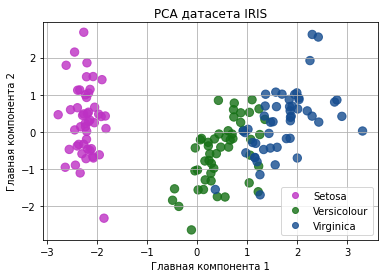

In [ ]:
cmap = ListedColormap(['#bd31c4', '#157015','#154c8f'])
scatter = plt.scatter(Z[:,0], -Z[:,1],
                      alpha=0.8, s=70, c=y,
                      cmap=cmap)
plt.legend(handles=scatter.legend_elements()[0],
           labels=['Setosa','Versicolour','Virginica'])
plt.grid();
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.title('PCA датасета IRIS');

## PCA из библиотеки scikit-learn

PCA с помощью сингулярного разложения матрицы. Сингулярное разложение матрицы - это разложение вида:

$$X=UDV^{T},$$

где столбцы ортогональной матрицы $U$ - это собственные векторы матрицы $XX^{T}$, столбцы ортогональной матрицы $V$ - собственные векторы матрицы $X^{T}X$, а на главной диагонали диагональной матрицы $D$ расположены собственные значения матриц $XX^{T}$ и $X^{T}X$ (они также называются сингулярными числами матрицы $X$). Если сингулярные числа из $D$ возвести в квадрат, то получим собственные числа матрицы $X^{T}X$.

Таким образом, матрицы $W$ и $V^{T}$ состоят из собственных векторов матрицы $X^{T}X$.

В библиотеке `numpy` реализована функция `numpy.linalg.svd(X)` для сингулярного разложения матриц.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
pca.get_params()

{'copy': True,
 'iterated_power': 'auto',
 'n_components': None,
 'n_oversamples': 10,
 'power_iteration_normalizer': 'auto',
 'random_state': None,
 'svd_solver': 'auto',
 'tol': 0.0,
 'whiten': False}

### Основные параметры метода

* `n_components`: int, default=`min(n_samples, n_features) - 1` - количество главных компонент
* `svd_solver`: {‘auto’, ‘full’, ‘arpack’, ‘randomized’}, default=’auto’ - метод SVD. Например, если ‘full’, то используется функция `scipy.linalg.svd`

In [ ]:
pca = PCA(n_components=4)
pca.fit(X_scaled)

PCA(n_components=4)

In [ ]:
# сингулярные числа (собственные значения)
pca.singular_values_ ** 2

array([437.77467248, 137.10457072,  22.01353134,   3.10722546])

In [ ]:
# доля от общей дисперсии
pca.explained_variance_ratio_

array([0.72962445, 0.22850762, 0.03668922, 0.00517871])

In [ ]:
# матрица с весами
pca.components_

array([[ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654],
       [ 0.37741762,  0.92329566,  0.02449161,  0.06694199],
       [-0.71956635,  0.24438178,  0.14212637,  0.63427274],
       [-0.26128628,  0.12350962,  0.80144925, -0.52359713]])

In [ ]:
W

array([[ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654],
       [-0.37741762, -0.92329566, -0.02449161, -0.06694199],
       [-0.71956635,  0.24438178,  0.14212637,  0.63427274],
       [ 0.26128628, -0.12350962, -0.80144925,  0.52359713]])

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit(X_scaled).transform(X_scaled)

In [ ]:
# матрица с весами
pca.components_

array([[ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654],
       [ 0.37741762,  0.92329566,  0.02449161,  0.06694199]])

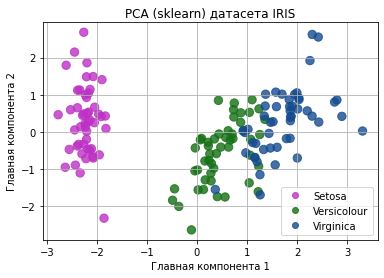

In [ ]:
scatter = plt.scatter(X_pca[:,0], X_pca[:,1],
                      alpha=0.8, s=70, c=y,
                      cmap=cmap)
plt.legend(handles=scatter.legend_elements()[0],
           labels=['Setosa','Versicolour','Virginica'])
plt.grid();
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.title('PCA (sklearn) датасета IRIS');

## Дополнительный материал

[PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

[Линейный дискриминантный анализ - LinearDiscriminantAnalysis](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html#sklearn.discriminant_analysis.LinearDiscriminantAnalysis)

## Задания

1. Обучите любую модель классификации на датасете IRIS до применения PCA и после него. Сравните качество классификации с использованием кросс-валидации (3 балла).

In [ ]:
# код

2. Напишите свою реализацию метода главных компонент с помощью сингулярного разложения с использованием функции [numpy.linalg.svd()](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.svd.html). Примените к данным на уроке и сравните ответы (6 баллов).

In [ ]:
# код

3. Загрузите датасет `prepared.csv. Найдите топ-5 наиболее значимых признаков, используя линейную модель и любую деревянную. Сравните результаты (3 балла).

In [ ]:
!gdown 1WonVHHMWLsLLE9sdKKTKPA-WfZTUUEra
df = pd.read_csv('/content/prepared.csv', index_col=0)

Downloading...
From: https://drive.google.com/uc?id=1WonVHHMWLsLLE9sdKKTKPA-WfZTUUEra
To: /content/prepared.csv
100% 1.64M/1.64M [00:00<00:00, 25.5MB/s]


In [ ]:
# код